<a href="https://colab.research.google.com/github/Jaysumm/majorProject/blob/main/MobileNetV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import zipfile

zip_ref = zipfile.ZipFile('archive.zip', 'r')
zip_ref.extractall('/content/dataset')
zip_ref.close()

In [ ]:
import os

os.rename(
    "/content/dataset/Grape Plant from Plant Village Dataset",
    "/content/dataset/grape"
)

In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

splitfolders.ratio(
    "/content/dataset/grape",
    output="/content/grape_split",
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

Copying files: 4062 files [00:00, 7368.35 files/s]


In [ ]:
import os

base_path = "/content/grape_split"

# folders: train, val, test
splits = ["train", "val", "test"]

for split in splits:
    print(f"\n===== {split.upper()} =====")
    split_path = os.path.join(base_path, split)

    # list each class folder
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        # count images inside this class
        count = len(os.listdir(class_path))

        print(f"{class_name}: {count} images")


===== TRAIN =====
Grape___Black_rot: 826 images
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 753 images
Grape___Esca_(Black_Measles): 968 images
Grape___healthy: 296 images

===== VAL =====
Grape___Black_rot: 177 images
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 161 images
Grape___Esca_(Black_Measles): 207 images
Grape___healthy: 63 images

===== TEST =====
Grape___Black_rot: 177 images
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 162 images
Grape___Esca_(Black_Measles): 208 images
Grape___healthy: 64 images


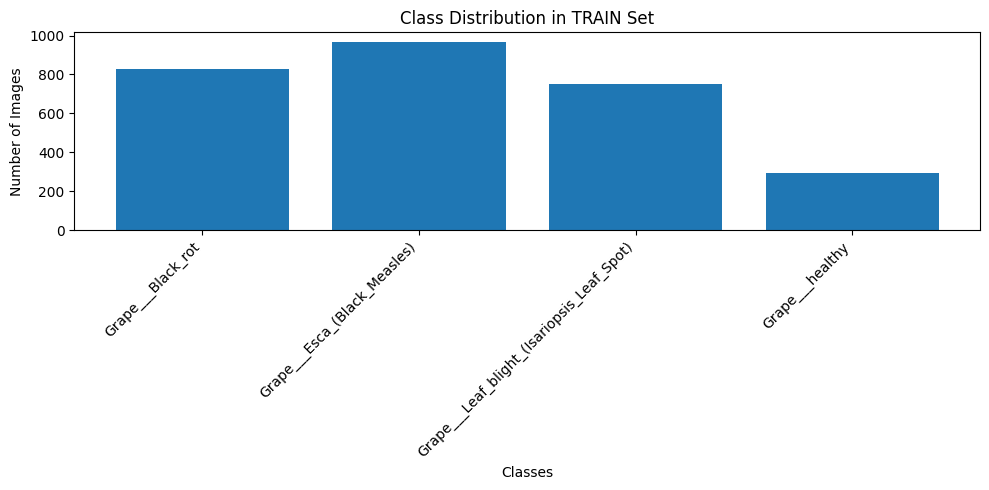

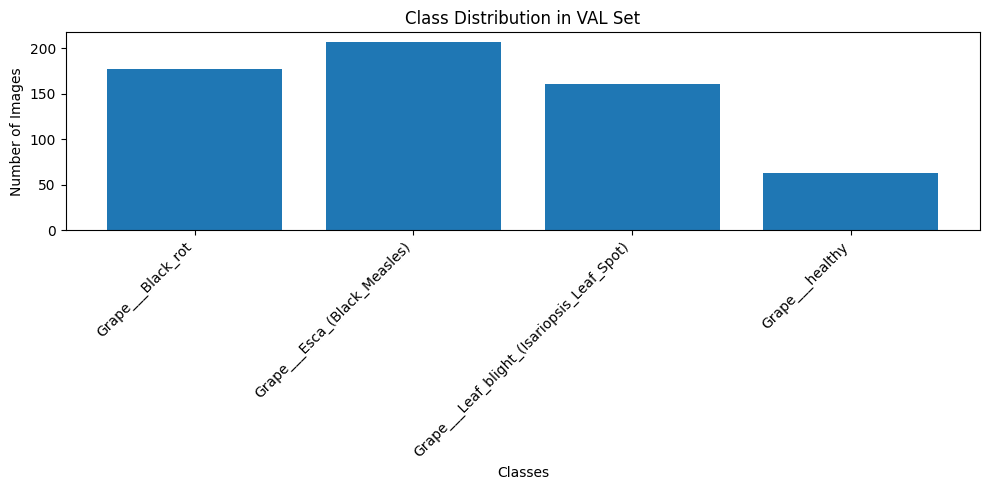

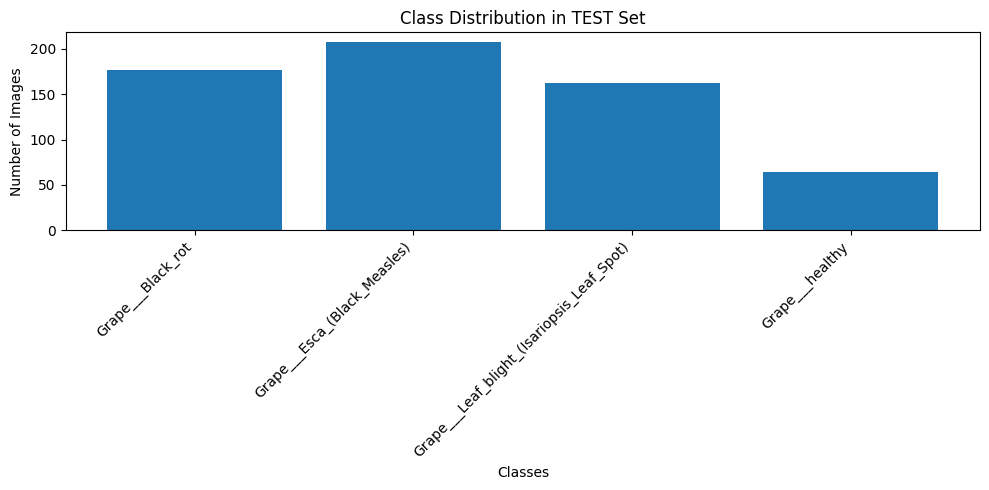

In [ ]:
import os
import matplotlib.pyplot as plt

base_path = "/content/grape_split"

splits = ["train", "val", "test"]

for split in splits:
    split_path = os.path.join(base_path, split)

    class_names = []
    counts = []

    # Count images for each class
    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)
        num_images = len(os.listdir(class_path))

        class_names.append(class_name)
        counts.append(num_images)

    # Plot the bar graph
    plt.figure(figsize=(10, 5))
    plt.bar(class_names, counts)
    plt.title(f"Class Distribution in {split.upper()} Set")
    plt.xlabel("Classes")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
import os
import shutil

original_train = "/content/grape_split/train"
balanced_train = "/content/grape_balanced/train"

# Create new directory
os.makedirs(balanced_train, exist_ok=True)

classes = sorted(os.listdir(original_train))

# Copy original folders & images
for cls in classes:
    src = os.path.join(original_train, cls)
    dst = os.path.join(balanced_train, cls)

    os.makedirs(dst, exist_ok=True)
    print(f"Copying {cls} ...")

    for file in os.listdir(src):
        shutil.copy(os.path.join(src, file), os.path.join(dst, file))

print("✅ Original training data copied to balanced folder!")

Copying Grape___Black_rot ...
Copying Grape___Esca_(Black_Measles) ...
Copying Grape___Leaf_blight_(Isariopsis_Leaf_Spot) ...
Copying Grape___healthy ...
✅ Original training data copied to balanced folder!


In [ ]:
class_counts = {
    cls: len(os.listdir(os.path.join(balanced_train, cls)))
    for cls in classes
}

target = max(class_counts.values())
print("\nTarget per class:", target)


Target per class: 968


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import numpy as np

aug = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

for cls in classes:
    cls_path = os.path.join(balanced_train, cls)
    current = len(os.listdir(cls_path))
    needed = target - current

    print(f"\nClass: {cls}")
    print(f"Existing: {current} | To generate: {needed}")

    if needed <= 0:
        continue

    images = os.listdir(cls_path)
    i = 0

    while i < needed:
        img_path = os.path.join(cls_path, images[i % len(images)])
        img = load_img(img_path, target_size=(224, 224))
        x = img_to_array(img)
        x = np.expand_dims(x, axis=0)

        for batch in aug.flow(
            x,
            batch_size=1,
            save_to_dir=cls_path,
            save_prefix=cls.replace(" ", "_"),
            save_format='jpg'
        ):
            i += 1
            if i >= needed:
                break


Class: Grape___Black_rot
Existing: 826 | To generate: 142

Class: Grape___Esca_(Black_Measles)
Existing: 968 | To generate: 0

Class: Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Existing: 753 | To generate: 215

Class: Grape___healthy
Existing: 296 | To generate: 672


In [ ]:
print("\n=== BALANCED TRAIN DATASET ===")
for cls in classes:
    print(cls, ":", len(os.listdir(os.path.join(balanced_train, cls))))


=== BALANCED TRAIN DATASET ===
Grape___Black_rot : 966
Grape___Esca_(Black_Measles) : 968
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 968
Grape___healthy : 935


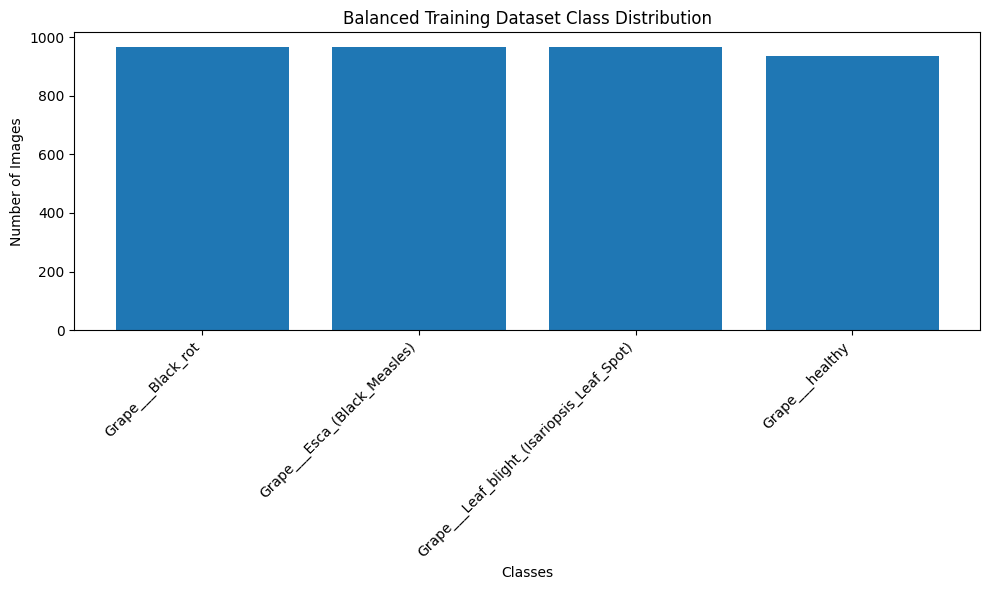

In [ ]:
import os
import matplotlib.pyplot as plt

balanced_train = "/content/grape_balanced/train"

classes = sorted(os.listdir(balanced_train))
counts = [len(os.listdir(os.path.join(balanced_train, cls))) for cls in classes]

plt.figure(figsize=(10,6))
plt.bar(classes, counts)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Balanced Training Dataset Class Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32        # Safe for T4
EPOCHS_HEAD = 10       # Feature extractor training
EPOCHS_FINE = 60       # Transfer learning (teacher wants this)
TOTAL_EPOCHS = 70

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    "/content/grape_balanced/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_gen = val_datagen.flow_from_directory(
    "/content/grape_split/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

Found 3837 images belonging to 4 classes.
Found 608 images belonging to 4 classes.


In [ ]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
output = Dense(4, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_head = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_HEAD
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 81s 516ms/step - accuracy: 0.6537 - loss: 0.8605 - val_accuracy: 0.9276 - val_loss: 0.2272
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 45s 371ms/step - accuracy: 0.9342 - loss: 0.2002 - val_accuracy: 0.9375 - val_loss: 0.1610
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 380ms/step - accuracy: 0.9550 - loss: 0.1343 - val_accuracy: 0.9474 - val_loss: 0.1456
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 382ms/step - accuracy: 0.9581 - loss: 0.1268 - val_accuracy: 0.9605 - val_loss: 0.1136
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 383ms/step - accuracy: 0.9564 - loss: 0.1113 - val_accuracy: 0.9638 - val_loss: 0.1090
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 45s 376ms/step - accuracy: 0.9599 - loss: 0.1097 - val_accuracy: 0.9638 - val_loss: 0.1041
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 379ms/step - accuracy: 0.9727 - loss: 0.0845 - val_accuracy: 0.9688 - val_loss: 0.0843
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 45s 378ms/step - accuracy: 0.9778 - loss: 0

In [ ]:
for layer in base_model.layers[-40:]:
    layer.trainable = True


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=5,
        min_lr=1e-6
    )
]


In [ ]:
history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINE,
    callbacks=callbacks
)


Epoch 1/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 81s 507ms/step - accuracy: 0.8380 - loss: 0.5705 - val_accuracy: 0.9671 - val_loss: 0.0809 - learning_rate: 1.0000e-05
Epoch 2/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 47s 389ms/step - accuracy: 0.9573 - loss: 0.1238 - val_accuracy: 0.9688 - val_loss: 0.0782 - learning_rate: 1.0000e-05
Epoch 3/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 45s 379ms/step - accuracy: 0.9651 - loss: 0.0930 - val_accuracy: 0.9704 - val_loss: 0.0747 - learning_rate: 1.0000e-05
Epoch 4/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 384ms/step - accuracy: 0.9729 - loss: 0.0715 - val_accuracy: 0.9737 - val_loss: 0.0699 - learning_rate: 1.0000e-05
Epoch 5/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 47s 393ms/step - accuracy: 0.9783 - loss: 0.0704 - val_accuracy: 0.9753 - val_loss: 0.0592 - learning_rate: 1.0000e-05
Epoch 6/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 385ms/step - accuracy: 0.9743 - loss: 0.0738 - val_accuracy: 0.9819 - val_loss: 0.0534 - learning_rate: 1.0000e-05
Epoch 7/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 46s 38

In [ ]:
train_acc = history_head.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_head.history['val_accuracy'] + history_fine.history['val_accuracy']

train_loss = history_head.history['loss'] + history_fine.history['loss']
val_loss = history_head.history['val_loss'] + history_fine.history['val_loss']

epochs = range(1, len(train_acc) + 1)


In [ ]:
test_gen = val_datagen.flow_from_directory(
    "/content/grape_split/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

loss, acc = model.evaluate(test_gen)
print("Test Accuracy:", acc)

Found 611 images belonging to 4 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 586ms/step - accuracy: 0.9933 - loss: 0.0155
Test Accuracy: 0.9967266917228699


In [ ]:
test_loss, test_accuracy = model.evaluate(test_gen)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9933 - loss: 0.0155
Test Loss: 0.0082
Test Accuracy: 99.67%


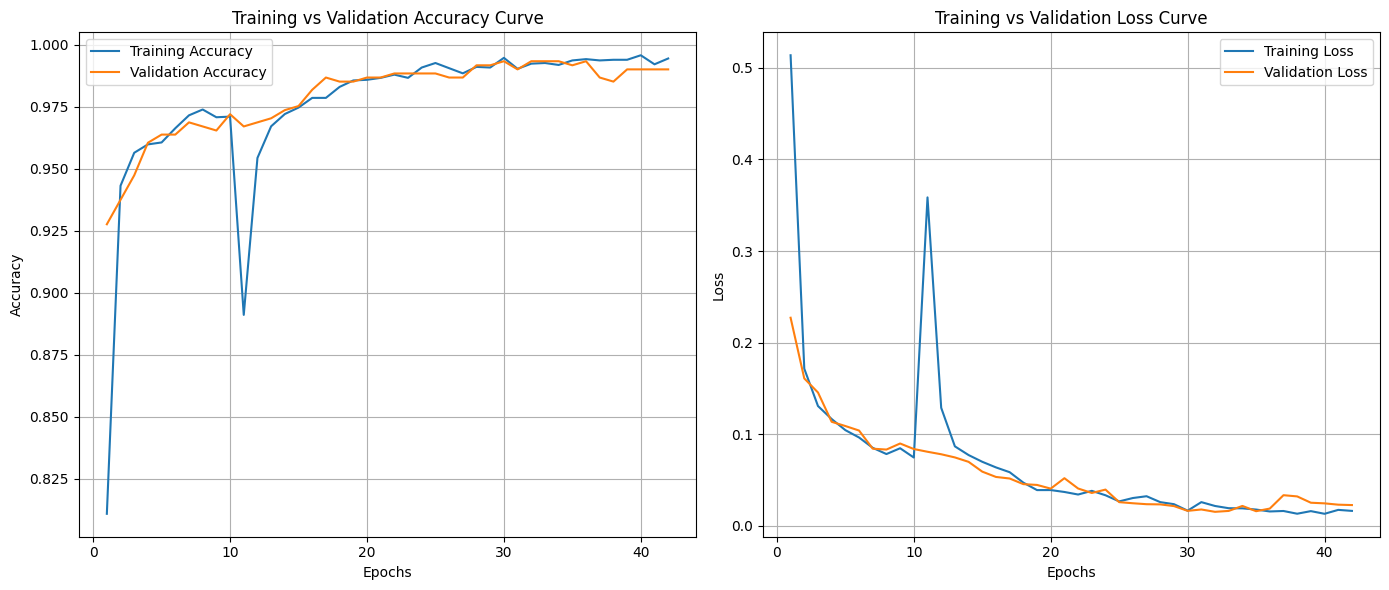

In [ ]:
import matplotlib.pyplot as plt

# --------- Combine Accuracy ---------
train_acc = history_head.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_head.history['val_accuracy'] + history_fine.history['val_accuracy']

# --------- Combine Loss ---------
train_loss = history_head.history['loss'] + history_fine.history['loss']
val_loss = history_head.history['val_loss'] + history_fine.history['val_loss']

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(14, 6))

# =====================================================
# Curve 1: Training vs Validation Accuracy
# =====================================================
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# =====================================================
# Curve 2: Training vs Validation Loss
# =====================================================
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

# Reset generator to avoid index issues
test_gen.reset()

# True labels
y_true = test_gen.classes

# Predict probabilities
y_pred_prob = model.predict(test_gen)

# Predicted class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Class names
class_names = list(test_gen.class_indices.keys())

print("Classes:", class_names)

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 297ms/step
Classes: ['Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy']


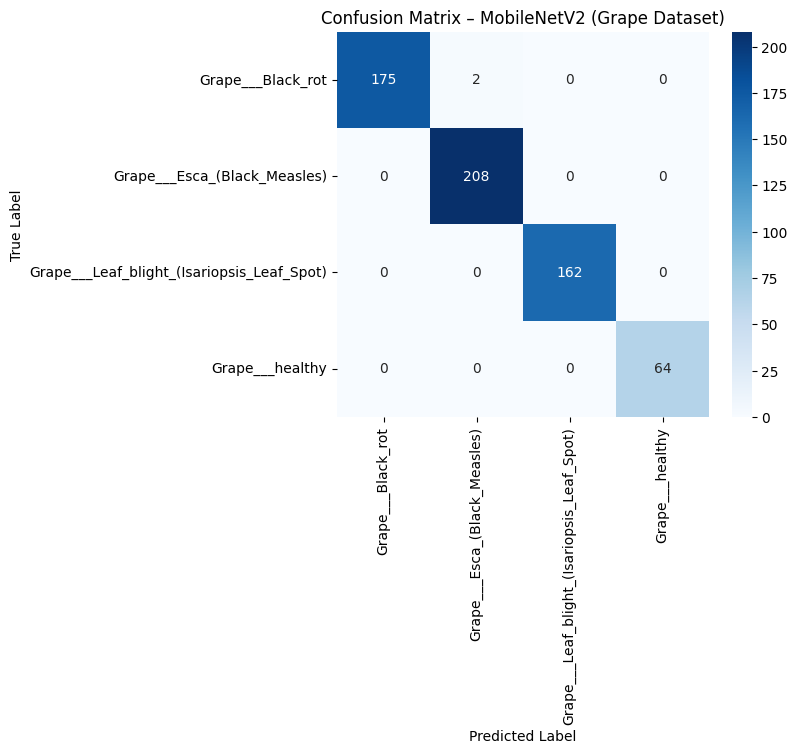

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – MobileNetV2 (Grape Dataset)")
plt.show()

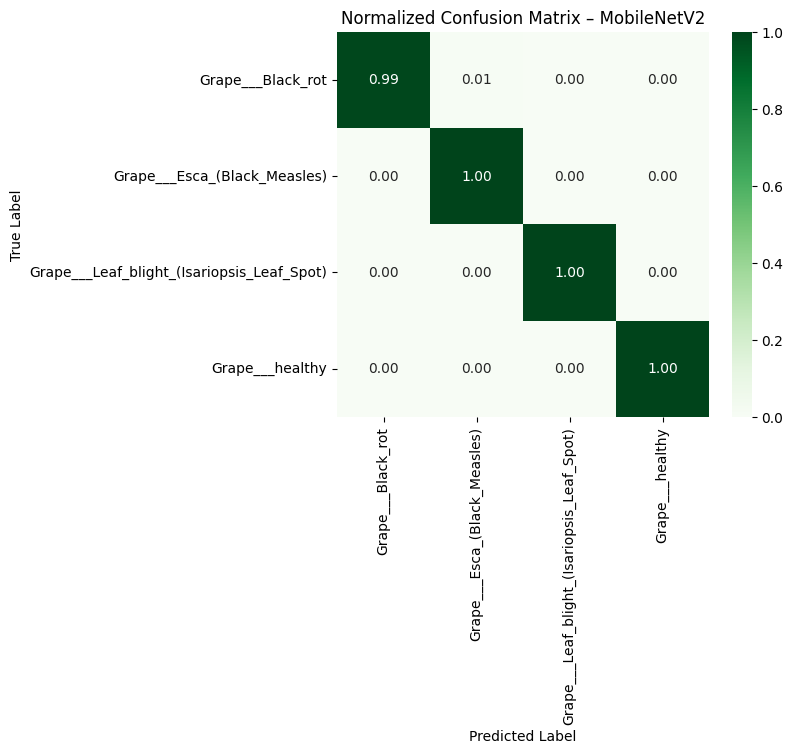

In [ ]:
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix – MobileNetV2")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("📊 Classification Report – MobileNetV2\n")
print(report)

📊 Classification Report – MobileNetV2

                                            precision    recall  f1-score   support

                         Grape___Black_rot     1.0000    0.9887    0.9943       177
              Grape___Esca_(Black_Measles)     0.9905    1.0000    0.9952       208
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)     1.0000    1.0000    1.0000       162
                           Grape___healthy     1.0000    1.0000    1.0000        64

                                  accuracy                         0.9967       611
                                 macro avg     0.9976    0.9972    0.9974       611
                              weighted avg     0.9968    0.9967    0.9967       611



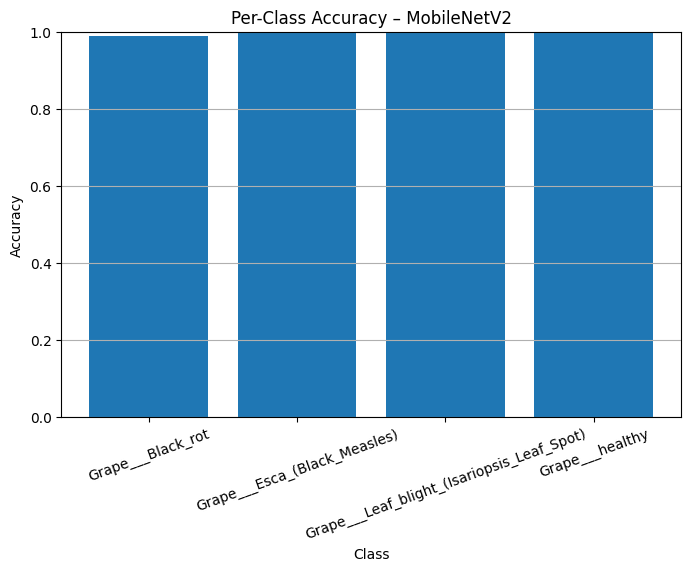

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion Matrix (already predicted earlier)
cm = confusion_matrix(y_true, y_pred)

# Per-class accuracy = diagonal / row sum
class_accuracy = cm.diagonal() / cm.sum(axis=1)

# Plot
plt.figure(figsize=(8, 5))
plt.bar(class_names, class_accuracy)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xlabel("Class")
plt.title("Per-Class Accuracy – MobileNetV2")
plt.xticks(rotation=20)
plt.grid(axis='y')

plt.show()

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

In [ ]:
for layer in model.layers[::-1]:
    if isinstance(layer, tf.keras.layers.Conv2D):
        print(layer.name)
        break


Conv_1


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()


In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def load_image(img_path, target_size=(224, 224)):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=target_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)   # 🔥 IMPORTANT
    return img, img_array


In [ ]:
def display_gradcam(original_img, heatmap, alpha=0.4):
    # Convert PIL image to numpy array
    img = np.array(original_img)

    # Normalize heatmap safely
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8

    # Resize heatmap to image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Convert to 0–255 and apply colormap
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Convert BGR → RGB
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Superimpose
    superimposed_img = heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    # Plot
    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Grad-CAM Visualization")
    plt.imshow(superimposed_img)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
last_conv_layer_name = "Conv_1"


📌 Class: Grape___Black_rot
🖼️ Image: image (428).JPG


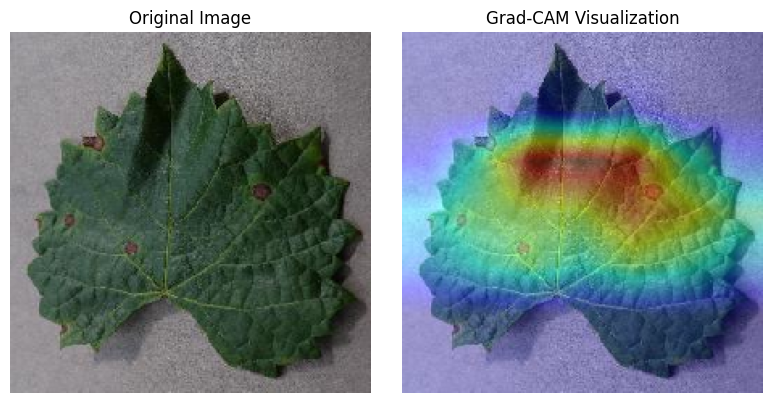


📌 Class: Grape___Esca_(Black_Measles)
🖼️ Image: image (377).JPG


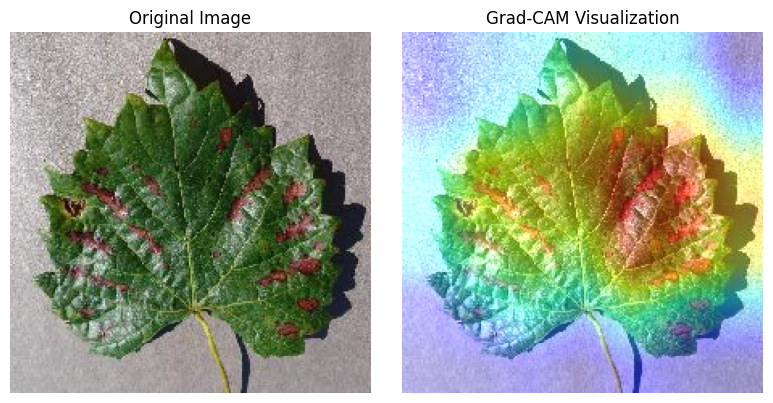


📌 Class: Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
🖼️ Image: image (524).JPG


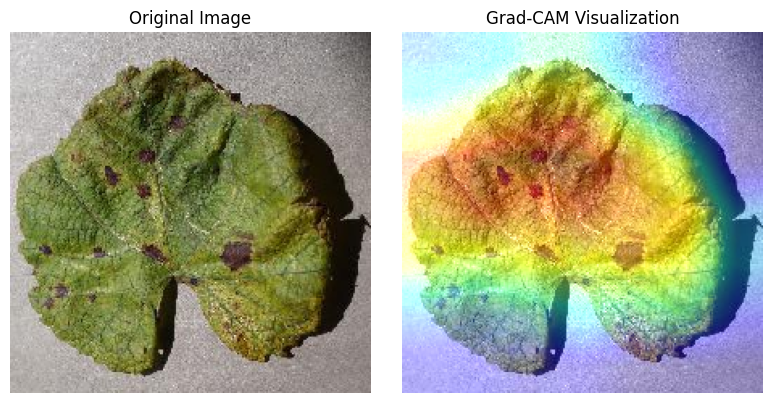


📌 Class: Grape___healthy
🖼️ Image: image (273).JPG


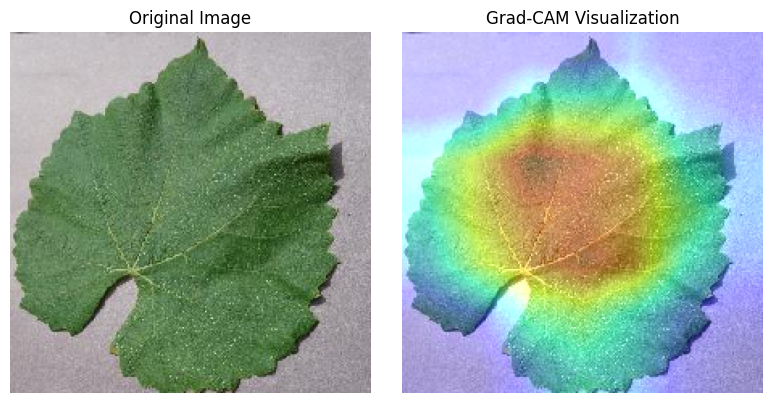

In [ ]:
test_dir = "/content/grape_split/test"

# Always sort for consistency
class_names = sorted(
    [d for d in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, d))]
)

for cls in class_names:
    cls_path = os.path.join(test_dir, cls)

    # Pick a deterministic but valid image
    img_list = sorted(os.listdir(cls_path))
    img_name = img_list[len(img_list)//2]   # middle image (safer than first)
    img_path = os.path.join(cls_path, img_name)

    print(f"\n📌 Class: {cls}")
    print(f"🖼️ Image: {img_name}")

    # Load image
    original_img, img_array = load_image(img_path)

    # Get class index explicitly
    true_class_index = class_names.index(cls)

    # Generate Grad-CAM for TRUE class
    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name,
        pred_index=true_class_index
    )

    display_gradcam(original_img, heatmap)


In [ ]:
import os

base_path = "/content/drive/MyDrive/Grape_Project/saved_models"
os.makedirs(base_path, exist_ok=True)

print("Folder ready:", base_path)

Folder ready: /content/drive/MyDrive/Grape_Project/saved_models


In [ ]:
model.save("/content/drive/MyDrive/Grape_Project/saved_models/mobilenetv2_grape_01.keras")
print("✅ MobileNetV2 model saved successfully")

✅ MobileNetV2 model saved successfully
